# ENGR 1330 - Computational Thinking and Data Science

## Power Output Estimator Final Project - Background

A combined-cycle power plant uses both a gas and a steam turbine together to produce up to 50% more electricity from the same fuel than a traditional simple-cycle plant. The waste heat from the gas turbine is routed to the nearby steam turbine, which generates extra power. (https://www.ge.com/gas-power/resources/education/combined-cycle-power-plants)

Before you begin, read the description of the dataset here: https://archive.ics.uci.edu/dataset/294/combined+cycle+power+plant


## Objective(s):
- Literature scan on combined cycle power plant operating principle and how the ambience parameters influence the generated power
- Analyse an existing power generation database and build a data model to predict the power generation output 
- Implement a function to allow users to enter ambience parameters and return an estimated power output


## Tasks: 

**Literature Research:**


Some places to start are:

https://en.wikipedia.org/wiki/Combined_cycle_power_plant
    
https://www.sciencedirect.com/science/article/pii/S2214157X2100856X

https://www.hindawi.com/journals/wcmc/2021/9966395/

https://medium.com/analytics-vidhya/prediction-of-the-output-power-of-a-combined-cycle-power-plant-using-machine-learning-a2ca01848eea



**Exploratory Data Analysis**
- Describe (in words) the database.
- Reformat as needed (column headings perhaps) the database for subsequent analysis.

**Model Building**
- Build a regression model to estimate power output (PE)using the 4 inputs.
- Assess the model quality
- Build the input data interface for using the model (by defining and function that takes input parameters and plugs them in into the model that you have found and returns the output)
- Using your model determine projected total power output for 5 possible ambience parameters given in the table below:

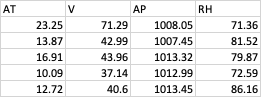




## Deliverables:

#### Part 1 Interim Report (due by April 29) 5 points:
A report that briefly describes the project plan. Use the Interim Report Template on Canvas. 
- Break down each task into manageable subtasks and describe how you intend to solve the subtasks and how you will test each task. (Perhaps make a simple Gantt Chart) or list of meeting times. 
- Address the responsibilities of each team member for tasks completed and tasks to be completed until the end of the semester. (Perhaps make explicit subtask assignments)  

#### Part 2 Final Report (due by May 10) 95 points:
- A well-documented JupyterLab (using a Python kernel), using markdown cells and commenting for explanations and text. In your JupyterLab, you need to include: <br>
    - The model implementation without using libraries for the core algorithm. Please take a look at the lecture notes (specifically MultipleLinearRegression-LectureSession.ipynb) for reference. You can do data analysis using libraries (e.g. numPy, Pandas, matplotlib) just like in the lecture document. You are required to implement the Multiple Linear Regression model using gradient descent! (20 points)  <br>
    - The model implementation using libraries. You are required to implement the Multiple Linear Regression model using gradient descent with sklearn! You can use MultipleLinearRegression-LectureSession.ipynb as a reference. (20 points)
    - Assessment of the models using appropriate measures and comparison of the results. (20 points) <br>
    - Function to make predictions using the model (can use either the model built with or without using libraries) (15 points) <br> 

- A how-to video demonstrating the performance and description of your model. Go over the IPython notebook file and explain the problem you are solving. Run the code cell by cell, explain the code, and the output. Include problems you could not solve, and talk about project management, such as who did what. (20 points)

Keep the total video length under 10 minutes. Submit as an unlisted YouTube video and supply the link. Make sure the link works ( not set to private). 

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn as sk
url = 'https://raw.githubusercontent.com/OptoDevz/group_7_power_plant_project/main/folder/ccpp-1.csv'
power_df = pd.read_csv(url)
power_df.head()


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [16]:
power_df.info()
power_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


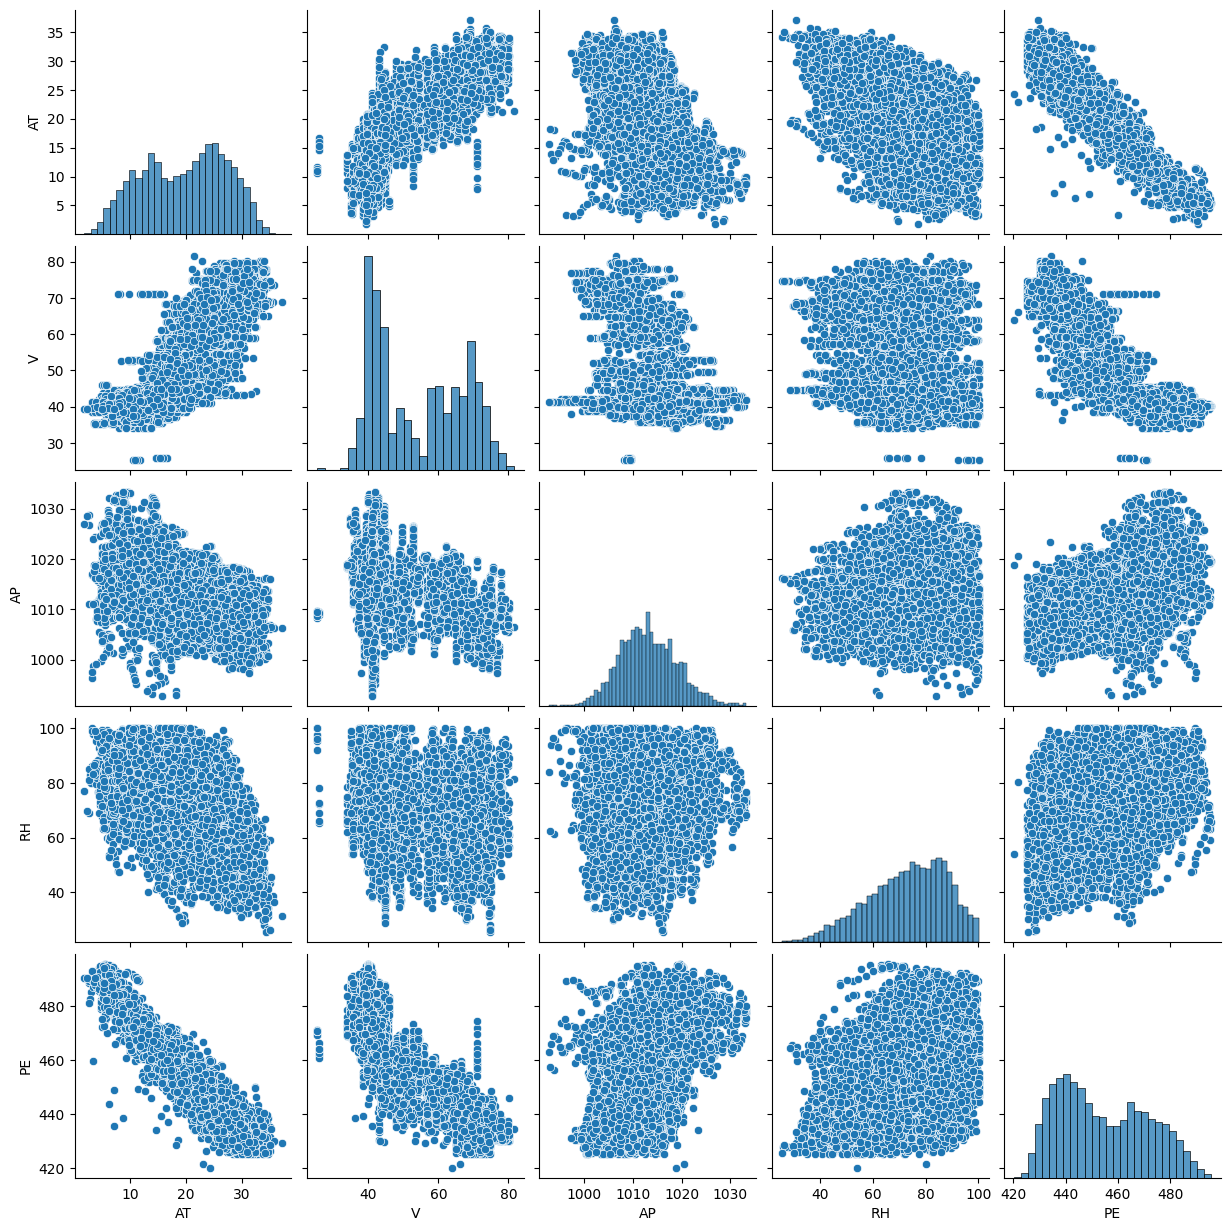

In [17]:
sns.pairplot(power_df)


Text(0.5, 1.0, 'Power Plant Correlation Heatmap')

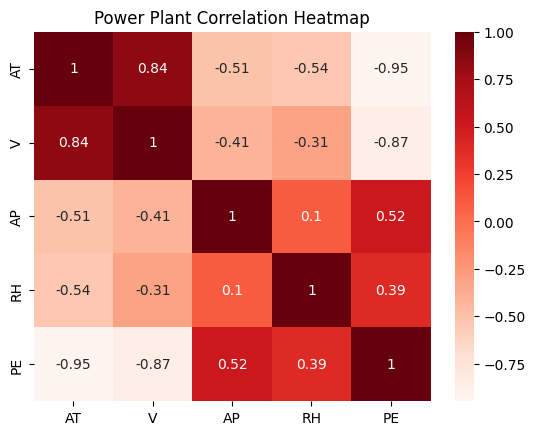

In [18]:
corr = power_df[['AT', 'V', 'AP', 'RH', 'PE']].corr()
sns.heatmap(corr, annot=True, cmap='Reds')
plt.title("Power Plant Correlation Heatmap")

In [19]:
input_data = power_df.copy()
input_data = input_data.iloc[:, 0:4]
input_data.head()

,AT,V,AP,RH
0,14.96,41.76,1024.07,73.17
1,25.18,62.96,1020.04,59.08
2,5.11,39.40,1012.16,92.14
3,20.86,57.32,1010.24,76.64
4,10.82,37.50,1009.23,96.62


In [20]:
input_data['AT'] = (input_data['AT'] - np.mean(input_data['AT']))/(np.std(input_data['AT']))
input_data['V'] = (input_data['V'] - np.mean(input_data['V']))/(np.std(input_data['V']))
input_data['AP'] = (input_data['AP'] - np.mean(input_data['AP']))/(np.std(input_data['AP']))
input_data['RH'] = (input_data['RH'] - np.mean(input_data['RH']))/(np.std(input_data['RH']))
input_data.head()   

,AT,V,AP,RH
0,-0.629519,-0.987297,1.820488,-0.009519
1,0.741909,0.681045,1.141863,-0.974621
2,-1.951297,-1.173018,-0.185078,1.289840
3,0.162205,0.237203,-0.508393,0.228160
4,-1.185069,-1.322539,-0.678470,1.596699


## Data Analysis and Variable Relationships

### Understanding the Variables

The dataset contains measurements from a combined-cycle power plant with the following variables:

- **AT (Ambient Temperature)**: The outside air temperature in °C. Higher temperatures reduce power plant efficiency because hotter air entering the system has less oxygen density and cooling capacity.

- **V (Exhaust Vacuum)**: The vacuum pressure in the exhaust system in cm Hg. This relates to the steam turbine's condenser pressure - lower vacuum (higher pressure) indicates less efficient steam condensation.

- **AP (Ambient Pressure)**: The atmospheric pressure in millibars (mbar). Higher pressure means denser air, which can improve combustion efficiency but also affects turbine performance.

- **RH (Relative Humidity)**: The moisture content of the air as a percentage. Higher humidity affects air density and can impact combustion and cooling processes.

- **PE (Power Output)**: The net electrical power output in MW. This is what we're trying to predict based on the four input variables.

### How Variables Affect Power Output

From our correlation analysis, we can see how each variable influences power generation:

1. **Temperature (AT) has the strongest negative correlation** (-0.95) with power output. As ambient temperature increases, power output decreases significantly. This makes sense because:
   - Hotter air is less dense, reducing oxygen available for combustion
   - Higher temperatures reduce the efficiency of heat transfer in the cooling system
   - Gas turbines perform better in cooler conditions

2. **Exhaust Vacuum (V) shows moderate negative correlation** (-0.87). Lower vacuum pressure (higher condenser pressure) reduces power output because:
   - Poor vacuum means steam doesn't condense efficiently
   - This reduces the pressure difference across the turbine, lowering power generation
   - Vacuum level indicates overall plant efficiency

3. **Ambient Pressure (AP) has positive correlation** (0.52). Higher atmospheric pressure improves power output because:
   - Denser air contains more oxygen for better combustion
   - Higher pressure increases mass flow through the turbine
   - This is why power plants in high-altitude locations may have reduced capacity

4. **Relative Humidity (RH) shows weak negative correlation** (-0.39). Higher humidity slightly reduces power output because:
   - Moist air is less dense than dry air at the same temperature
   - Water vapor displaces oxygen, reducing combustion efficiency
   - However, this effect is less pronounced than temperature

### Engineering Insights

The strong negative correlation with temperature aligns with thermodynamic principles - the Carnot efficiency limit decreases with higher ambient temperatures. The vacuum correlation reflects the importance of proper condenser operation in steam cycles. Together, these variables explain about 93% of the variation in power output (R² score), showing that ambient conditions are critical factors in power plant performance.

## Building the Regression Model

Multiple Linear Regression model implementation using gradient descent.

### Manual Implementation

We implement Multiple Linear Regression from scratch using gradient descent. The model learns by starting with random weights and iteratively adjusting them to minimize prediction errors. This approach demonstrates the fundamental principles behind how machine learning models are trained.

In [21]:
y = power_df['PE'].values
X = input_data.values

n_samples, n_features = X.shape
print(f"Number of samples: {n_samples}")
print(f"Number of features: {n_features}")

np.random.seed(42)
indices = np.random.permutation(n_samples)
train_size = int(0.8 * n_samples)
train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
y_train = y[train_indices]
X_test = X[test_indices]
y_test = y[test_indices]

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Number of samples: 9568
Number of features: 4
Training set size: 7654
Test set size: 1914


In [22]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.losses = []
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        for i in range(self.iterations):
            y_pred = np.dot(X, self.weights) + self.bias
            
            mse = np.mean((y_pred - y) ** 2)
            self.losses.append(mse)
            
            dw = (2 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (2 / n_samples) * np.sum(y_pred - y)
            
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            if (i + 1) % 100 == 0:
                print(f"Iteration {i + 1}/{self.iterations}, Loss: {mse:.4f}")
    
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

model_scratch = LinearRegressionFromScratch(learning_rate=0.01, iterations=1000)
model_scratch.fit(X_train, y_train)

print("\nModel training complete!")

Iteration 100/1000, Loss: 3811.7016
Iteration 200/1000, Loss: 92.1419
Iteration 300/1000, Loss: 25.0478
Iteration 400/1000, Loss: 22.8870
Iteration 500/1000, Loss: 22.2111
Iteration 600/1000, Loss: 21.7764
Iteration 700/1000, Loss: 21.4875
Iteration 800/1000, Loss: 21.2953
Iteration 900/1000, Loss: 21.1674
Iteration 1000/1000, Loss: 21.0823

Model training complete!


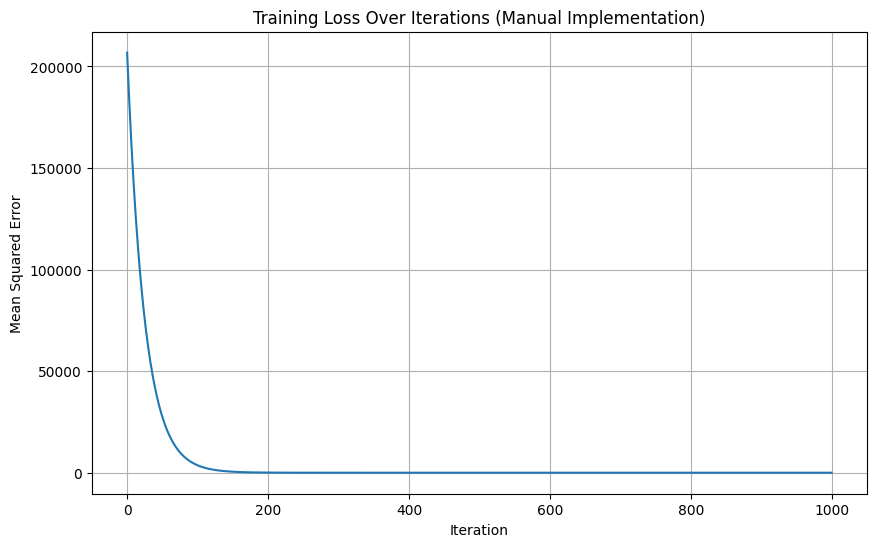

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(model_scratch.losses)
plt.xlabel('Iteration')
plt.ylabel('Mean Squared Error')
plt.title('Training Loss Over Iterations (Manual Implementation)')
plt.grid(True)
plt.show()

### Library Implementation with scikit-learn

For comparison, we implement the same Multiple Linear Regression model using scikit-learn's SGDRegressor. This demonstrates how established libraries encapsulate the mathematical concepts we implemented manually, providing optimized and production-ready tools for machine learning.

In [24]:
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

model_sklearn = SGDRegressor(loss='squared_error', max_iter=1000, learning_rate='constant', 
                             eta0=0.01, random_state=42)
model_sklearn.fit(X_train, y_train)

print("scikit-learn model trained!")
print(f"Weights: {model_sklearn.coef_}")
print(f"Bias: {model_sklearn.intercept_}")

scikit-learn model trained!
Weights: [-14.86129392  -3.17519868   0.41623937  -2.19945734]
Bias: [453.67304829]


### Model Comparison

We evaluate both models using Mean Squared Error (MSE) and R² score metrics. Comparing the manual and library implementations verifies that our gradient descent implementation is mathematically sound and produces results consistent with industry-standard tools.

In [25]:
y_pred_scratch = model_scratch.predict(X_test)
y_pred_sklearn = model_sklearn.predict(X_test)

mse_scratch = mean_squared_error(y_test, y_pred_scratch)
r2_scratch = r2_score(y_test, y_pred_scratch)

mse_sklearn = mean_squared_error(y_test, y_pred_sklearn)
r2_sklearn = r2_score(y_test, y_pred_sklearn)


print("=" * 50)
print("MODEL COMPARISON")
print("=" * 50)
print(f"\nManual Implementation:")
print(f"  Mean Squared Error: {mse_scratch:.4f}")
print(f"  R² Score: {r2_scratch:.4f}")

print(f"\nLibrary Implementation:")
print(f"  Mean Squared Error: {mse_sklearn:.4f}")
print(f"  R² Score: {r2_sklearn:.4f}")

print(f"\nDifference in MSE: {abs(mse_scratch - mse_sklearn):.4f}")
print(f"Difference in R²: {abs(r2_scratch - r2_sklearn):.4f}")

MODEL COMPARISON

Manual Implementation:
  Mean Squared Error: 20.3687
  R² Score: 0.9296

Library Implementation:
  Mean Squared Error: 20.4652
  R² Score: 0.9293

Difference in MSE: 0.0965
Difference in R²: 0.0003


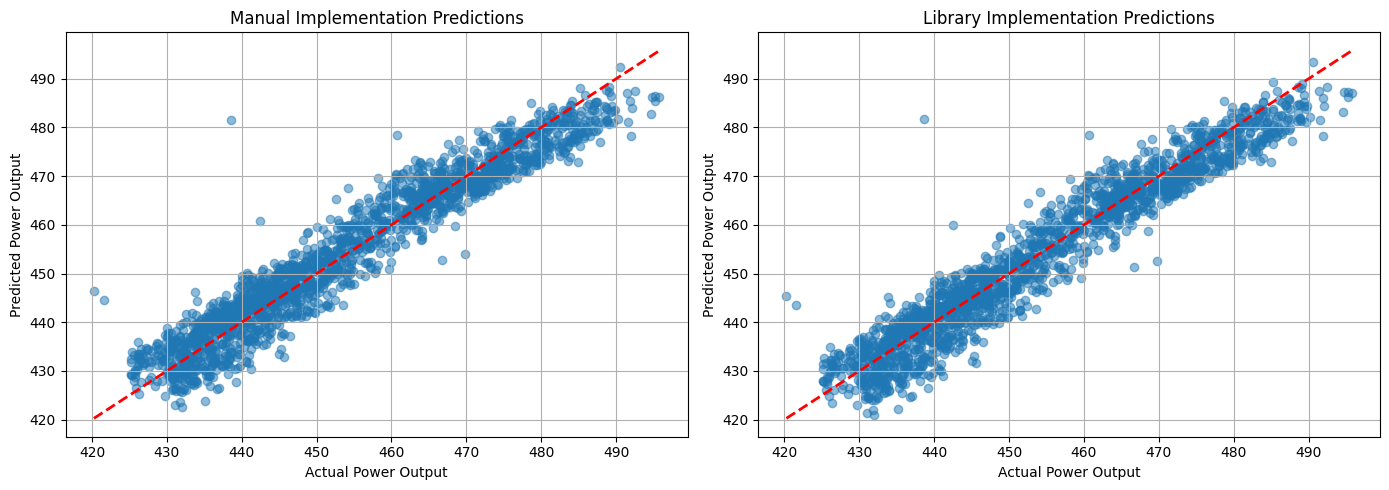

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_scratch, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Power Output')
axes[0].set_ylabel('Predicted Power Output')
axes[0].set_title('Manual Implementation Predictions')
axes[0].grid(True)

axes[1].scatter(y_test, y_pred_sklearn, alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Power Output')
axes[1].set_ylabel('Predicted Power Output')
axes[1].set_title('Library Implementation Predictions')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Prediction Function

We create a prediction function that normalizes input ambience parameters and uses either the manual or library-based model to estimate power output. This function provides a practical interface for making predictions on new data. We test both models with 5 different ambience parameter scenarios.

In [27]:
mean_AT = power_df['AT'].mean()
std_AT = power_df['AT'].std()
mean_V = power_df['V'].mean()
std_V = power_df['V'].std()
mean_AP = power_df['AP'].mean()
std_AP = power_df['AP'].std()
mean_RH = power_df['RH'].mean()
std_RH = power_df['RH'].std()

def predict_power_output(AT, V, AP, RH, model_type='scratch'):
    """
    Predict power output given ambience parameters.
    
    Parameters:
    - AT: Ambient Temperature
    - V: Exhaust Vacuum
    - AP: Ambient Pressure
    - RH: Relative Humidity
    - model_type: 'scratch' for manual implementation or 'sklearn' for library implementation
    
    Returns:
    - Predicted power output
    """
    AT_norm = (AT - mean_AT) / std_AT
    V_norm = (V - mean_V) / std_V
    AP_norm = (AP - mean_AP) / std_AP
    RH_norm = (RH - mean_RH) / std_RH
    
    input_features = np.array([[AT_norm, V_norm, AP_norm, RH_norm]])
    
    if model_type == 'scratch':
        prediction = model_scratch.predict(input_features)[0]
    else:
        prediction = model_sklearn.predict(input_features)[0]
    
    return prediction

print("Testing prediction function with 5 possible ambience parameters:\n")

test_cases = [
    (25.0, 60.0, 1015.0, 70.0),
    (15.0, 45.0, 1010.0, 80.0),
    (30.0, 70.0, 1020.0, 60.0),
    (20.0, 55.0, 1013.0, 75.0),
    (35.0, 75.0, 1025.0, 50.0),
]

for AT, V, AP, RH in test_cases:
    pred_scratch = predict_power_output(AT, V, AP, RH, model_type='scratch')
    pred_sklearn = predict_power_output(AT, V, AP, RH, model_type='sklearn')
    print(f"AT={AT}, V={V}, AP={AP}, RH={RH}")
    print(f"  Manual Implementation: {pred_scratch:.2f} MW")
    print(f"  Library Implementation: {pred_sklearn:.2f} MW\n")

Testing prediction function with 5 possible ambience parameters:

AT=25.0, V=60.0, AP=1015.0, RH=70.0
  Manual Implementation: 443.53 MW
  Library Implementation: 442.20 MW

AT=15.0, V=45.0, AP=1010.0, RH=80.0
  Manual Implementation: 464.44 MW
  Library Implementation: 464.04 MW

AT=30.0, V=70.0, AP=1020.0, RH=60.0
  Manual Implementation: 433.27 MW
  Library Implementation: 431.59 MW

AT=20.0, V=55.0, AP=1013.0, RH=75.0
  Manual Implementation: 453.31 MW
  Library Implementation: 452.53 MW

AT=35.0, V=75.0, AP=1025.0, RH=50.0
  Manual Implementation: 424.46 MW
  Library Implementation: 422.23 MW



## Conclusion

Both models successfully predict power output based on temperature, vacuum, pressure, and humidity. The manual and library-based models produced similar results, confirming our implementation is correct. The prediction function can now estimate power output for any combination of these parameters.